# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [63]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import UndirectedGraph


In [64]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [65]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")


# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)

In [66]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  50%|█████     | 1/2 [00:00<00:00,  6.33it/s]

Finished loading graph_eu_airlines


Loading GML Files: 100%|██████████| 2/2 [00:00<00:00,  2.29it/s]

Finished loading graph_power


In [67]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:01<00:14,  1.43s/it]

Finished loading WDN_1997


Loading GML WTW Files:  27%|██▋       | 3/11 [00:01<00:03,  2.11it/s]

Finished loading WDN_1992
Finished loading WDN_2000


Loading GML WTW Files:  36%|███▋      | 4/11 [00:02<00:02,  2.43it/s]

...

Finished loading WDN_1996
Finished loading WDN_1995


Loading GML WTW Files:  91%|█████████ | 10/11 [00:03<00:00,  3.66it/s]

Finished loading WDN_1999


Loading GML WTW Files: 100%|██████████| 11/11 [00:03<00:00,  2.77it/s]

Finished loading WDN_2001


# I ERGMs

In [68]:
graphs

{'graph_eu_airlines': <networkx.classes.graph.Graph at 0x13a293f50>,
 'graph_power': <networkx.classes.graph.Graph at 0x13a503fd0>}

In [69]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x137c02650>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x13906e4d0>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x129548850>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x1291f6950>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x13a10a850>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x12c36e490>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x139352110>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x12850e910>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x1367d2750>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x1391cb8d0>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x1376b5a10>}

## 1. Compute the strength assortativity coefficient on the data.
Hint: Pay attention: the underlying data (WTW) are weighted and direted, meaning you should account
for four different kind of assortativity: in–in, in–out, out–in, out–out.

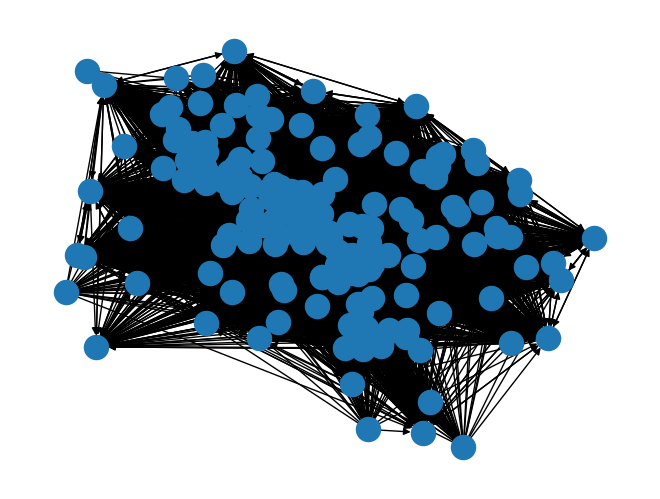

In [70]:
nx.draw(G=graphs_wtn["WDN_1997"])

In [71]:
for graph_name, graph in graphs_wtn.items():
    pass

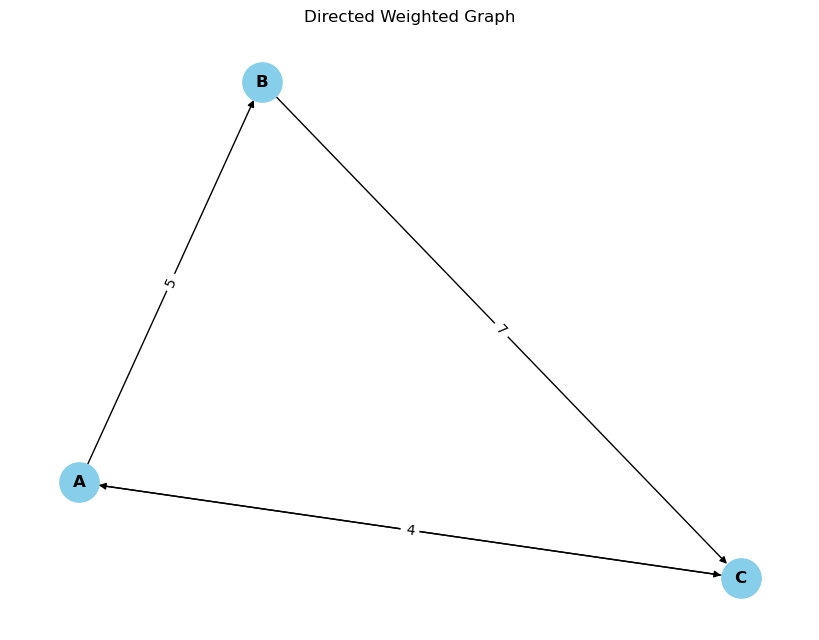

In [72]:
G = nx.DiGraph()

# Add weighted edges
G.add_edge('A', 'B', weight=5)
G.add_edge('A', 'C', weight=3)
G.add_edge('B', 'C', weight=7)
G.add_edge('C', 'A', weight=4)

# Plot the graph
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, seed=42)  # Set the layout for consistent plotting

# Draw nodes and labels
nx.draw(G, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold')

# Draw edge labels with weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Directed Weighted Graph')
plt.show()

In [79]:
def calculate_assortativity(graph):
    in_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='in', weight='weight')
    in_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='out', weight='weight')
    out_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='in', weight='weight')
    out_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='out', weight='weight')

    # Create a dictionary to store assortativity values
    assortativity_dict = {
        "In-In Assortativity": in_in,
        "In-Out Assortativity": in_out,
        "Out-In Assortativity": out_in,
        "Out-Out Assortativity": out_out
    }

    # Return dictionary with assortativity values
    return assortativity_dict

{'In-In Assortativity': -0.073686352073877,
 'In-Out Assortativity': -0.07132955497657792,
 'Out-In Assortativity': -0.07171683897072376,
 'Out-Out Assortativity': -0.069700798720094}

In [85]:
assortativities = {}
for graph_name, graph in graphs_wtn.items():
    assortativities[graph_name] = calculate_assortativity(graph=graph)
    
print(assortativities)

{'WDN_1997': {'In-In Assortativity': -0.073686352073877, 'In-Out Assortativity': -0.07132955497657792, 'Out-In Assortativity': -0.07171683897072376, 'Out-Out Assortativity': -0.069700798720094}, 'WDN_1992': {'In-In Assortativity': -0.04868776409103533, 'In-Out Assortativity': -0.04664740434092387, 'Out-In Assortativity': -0.05986979308699135, 'Out-Out Assortativity': -0.057603189205412644}, 'WDN_2000': {'In-In Assortativity': -0.0631970717497539, 'In-Out Assortativity': -0.06467170213846346, 'Out-In Assortativity': -0.06539073425903165, 'Out-Out Assortativity': -0.06730072607061886}, 'WDN_1998': {'In-In Assortativity': -0.06557057818395721, 'In-Out Assortativity': -0.06540616504184193, 'Out-In Assortativity': -0.06572057397949527, 'Out-Out Assortativity': -0.06583617855060359}, 'WDN_1994': {'In-In Assortativity': -0.07868988970611884, 'In-Out Assortativity': -0.07622523439269807, 'Out-In Assortativity': -0.0802250161794805, 'Out-Out Assortativity': -0.07800143058821395}, 'WDN_1993': {'

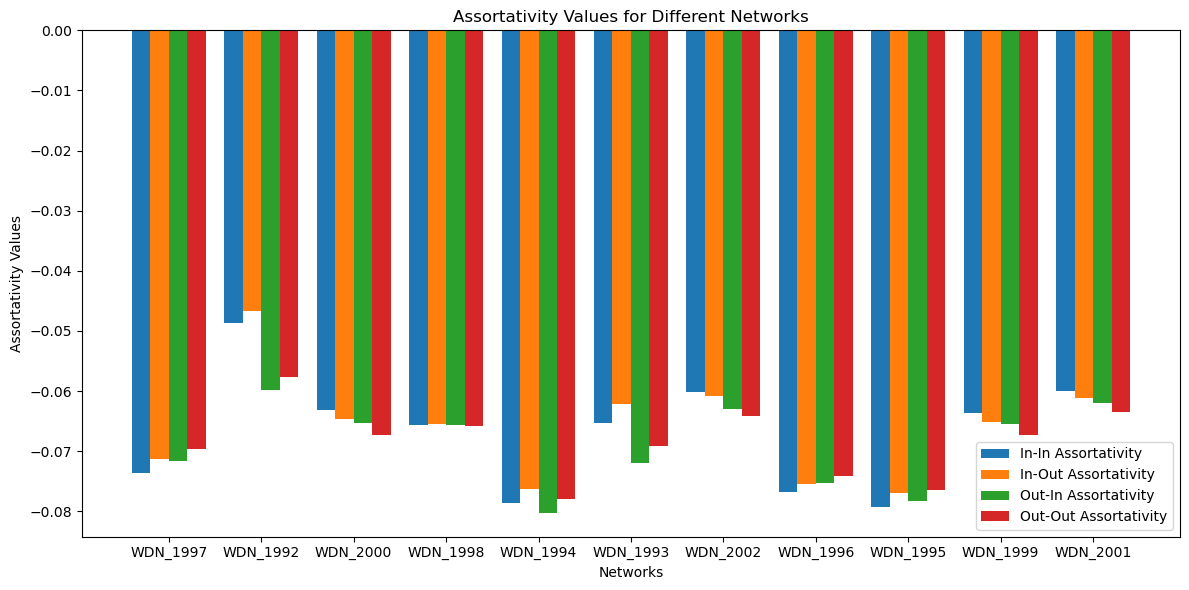

In [86]:
# Extracting graph names and assortativity values
graph_names = list(assortativities.keys())
keys = list(assortativities[graph_names[0]].keys())  # Extracting keys for assortativity values
values = {graph_name: [assortativities[graph_name][key] for key in keys] for graph_name in graph_names}

# Creating side-by-side bar plots for each network
bar_width = 0.2  # Width of each bar
index = np.arange(len(graph_names))  # Index for the networks

plt.figure(figsize=(12, 6))

for i, key in enumerate(keys):
    plt.bar(index + (i * bar_width), [values[graph_name][i] for graph_name in graph_names], bar_width, label=key)

plt.xlabel('Networks')
plt.ylabel('Assortativity Values')
plt.title('Assortativity Values for Different Networks')
plt.xticks(index + (bar_width * (len(keys) - 1) / 2), graph_names)
plt.legend()
plt.tight_layout()

plt.show()

## 2. Fit the Undirected Enhanced CM and Directed Enhanced CM using the CReMa method.
Hint: You can use the nemtropy package on networkx to deploy these methods. You can find some examples
at https://github.com/nicoloval/NEMtropy/blob/master/examples/Directed%20Graphs.
ipynb. For additional questions, do not hesitate to ask at the QA.

## 3. Sample 30 networks from the obtained ERGM distributions and measure the strength assortativity on all of them. Calculate average and standard deviation of each assortativity typology.

## 4. Plot strength assortativity as a function of time (the WTW network year), comparing the observed real value with the average and error bars obtained from the samples samples.
Hint: plot error bars as confidence intervals. Plot all pairs of assortativity for the undirected and directed
case(in-in, in-out, out-out)

## 5. Write a short paragraph to comment on the interpretation of strength assortativity for this dataset, and about the conclusions you can draw via the inference you made using the ERGM models.

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results.pdf`